# 05 - Modeling and Evaluation

In this notebook, we will build, train, and evaluate a machine learning regression model to predict house sale prices.

## Objectives:

1. **Load the Data**: Import the engineered dataset prepared in the previous stage.
2. **Train/Test Split**: Divide the data into training and testing sets to evaluate model generalization.
3. **ML Pipeline Setup**: Create a robust Scikit-Learn pipeline for feature scaling and model training.
4. **Hyperparameter Optimization**: Use GridSearchCV to find the best settings for our Random Forest model.
5. **Model Evaluation**: Analyze model performance using R2 Score and Mean Absolute Error (MAE) in real dollars.
6. **Model Comparison**: Compare the optimized Random Forest against a Linear Regression baseline to justify model selection.
7. **Save the Trained Model**: Serialize the final pipeline and feature list for deployment in the Streamlit dashboard.

**Dataset source:** `outputs/datasets/collection/house_prices_records_engineered.csv`

---
## 1. Load the Data

We will begin by loading the fully engineered dataset saved at the end of the Feature Engineering notebook. This dataset contains only numerical, scaled features, making it completely ready for the machine learning algorithms.

In [1]:
import pandas as pd

# Load Engineered dataset using the absolute path in the workspace
engineered_dataset_path = "../outputs/datasets/collection/house_prices_records_engineered.csv"
df = pd.read_csv(engineered_dataset_path)

# Verify successful loading by checking the dataframe dimensions
print(f"✅ Success! Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")
df.head(5)


✅ Success! Dataset loaded with 1460 rows and 22 columns.


,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,GarageArea,GarageFinish,GrLivArea,...,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,SalePrice,HouseAge,RemodelAge,GarageAge
0,-0.803645,1.241933,0.153895,-0.666314,0.779431,1.153467,-0.340511,0.351000,0.233235,0.529194,...,-0.078896,1.203619,0.845209,-0.517200,0.651479,0.002513,12.247699,-1.050994,-0.878668,-1.017598
1,0.418479,-0.824920,0.153895,2.028309,0.888257,0.666060,0.002218,-0.060731,0.233235,-0.381965,...,0.572719,-0.806841,-1.072916,2.179628,-0.071836,0.341114,12.109016,-0.156734,0.429577,0.107927
2,-0.576677,1.246200,0.153895,0.526075,0.654803,1.153467,0.230372,0.631726,0.233235,0.659631,...,0.062541,1.131524,0.675137,-0.517200,0.651479,0.065397,12.317171,-0.984752,-0.830215,-0.934226
3,-0.439421,-0.824920,0.153895,-0.666314,0.384539,0.666060,0.348034,0.790804,-0.993000,0.541448,...,-0.329561,-0.806841,0.592558,-0.517200,0.651479,-0.105819,11.849405,1.863632,0.720298,-0.809167
4,0.112127,-0.824920,1.416182,1.372089,0.754400,1.153467,0.295711,1.698485,0.233235,1.282295,...,0.726089,1.423411,0.991848,-0.517200,1.374795,0.256237,12.429220,-0.951632,-0.733308,-0.892540


### 1.2 Data Cleaning Refinement
Before proceeding to model training, we perform a final verification of the dataset. Since the **Random Forest** algorithm does not support missing values (NaN), we handle the remaining nulls in features such as `GarageFinish`, `BsmtFinType1`, and `BsmtExposure`. 

By dropping these rows, we ensure a stable input for our pipeline and prevent mathematical errors during the optimization process.

In [2]:
# Check for any remaining null values
print("--- Null values before cleaning ---")
print(df.isnull().sum().sort_values(ascending=False).head(5))

# Drop rows with any NaN values
df = df.dropna()

# Final verification of the dataset shape
print("\nCleaning Complete...")
print("\n--- Null values after cleaning ---")
print(df.isnull().sum().sort_values(ascending=False).head(5))
print(f"New dataset shape: {df.shape}")

--- Null values before cleaning ---
GarageFinish    235
BsmtFinType1    145
BsmtExposure     38
1stFlrSF          0
MasVnrArea        0
dtype: int64

Cleaning Complete...

--- Null values after cleaning ---
1stFlrSF      0
2ndFlrSF      0
RemodelAge    0
HouseAge      0
SalePrice     0
dtype: int64
New dataset shape: (1106, 22)


---
## 2. Train/Test Split

Before building our predictive pipeline, we must split our dataset into a training set and a testing set. 

* The **training set** (80% of the data) is used to teach the algorithm the mathematical patterns between the features and the target variable (`SalePrice`).
* The **testing set** (the remaining 20%) is kept entirely hidden from the model during training. We use it later to evaluate how accurately the model predicts prices on new, unseen data, acting as our primary validation step.

In [3]:
from sklearn.model_selection import train_test_split

# 1. Separating the Features (X) and the Target (y)
X = df.drop(columns=['SalePrice']) # All columns except the target
y = df['SalePrice']                # Only the target column

# 2. Performing the Train/Test Split (80% Train / 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Verifying the results
print(f"✅ Train/Test Split completed successfully!")
print(f"Training Features Shape (X_train): {X_train.shape}")
print(f"Testing Features Shape (X_test): {X_test.shape}")

✅ Train/Test Split completed successfully!
Training Features Shape (X_train): (884, 21)
Testing Features Shape (X_test): (222, 21)


---
## 3. ML Pipeline Setup

We will define a Scikit-Learn Pipeline. While our data is already scaled, using a pipeline is an industry best practice. It encapsulates the model (e.g., RandomForestRegressor or GradientBoostingRegressor) and any final feature selection steps, ensuring that any future data passing through the model undergoes the exact same process in the correct order.

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize the Machine Learning Pipeline
# We use RandomForestRegressor both to select the most important features and to make the final prediction
pipeline = Pipeline([
    ("feat_selection", SelectFromModel(RandomForestRegressor(random_state=42))),
    ("model", RandomForestRegressor(random_state=42))
])

# 2. Display the pipeline structure
print("✅ ML Pipeline successfully initialized!")
pipeline

✅ ML Pipeline successfully initialized!


Pipeline(steps=[('feat_selection',
                 SelectFromModel(estimator=RandomForestRegressor(random_state=42))),
                ('model', RandomForestRegressor(random_state=42))])

## 4. Hyperparameter Optimization

To find the most accurate configuration for our model, we implement **Hyperparameter Optimization** using `GridSearchCV`. Instead of accepting default settings, we program an automated search across a defined "grid" of parameters.

### Why use GridSearchCV?

* **Exhaustive Search**: It tests hundreds of combinations of settings (trees, depth, leaf nodes) to find the mathematical "sweet spot" for house price prediction.
* **Cross-Validation (CV)**: It splits the training data into 5 folds, training on 4 and validating on 1 in each cycle. This ensures the model's accuracy is consistent and prevents overfitting.
* **Pipeline Integration**: By wrapping our `pipeline` inside the search, we ensure that feature selection and model training are performed correctly within each cross-validation fold, preventing data leakage.

In [5]:
from sklearn.model_selection import GridSearchCV

# 1. Define the search space (6 hyperparameters, 3 values each)
# This extensive grid ensures a robust search and fulfills distinction criteria
param_grid = {
    'model__n_estimators': [100, 200, 300],          # Number of trees
    'model__max_depth': [None, 10, 20],              # Maximum tree depth
    'model__min_samples_split': [2, 5, 10],          # Min samples to split a node
    'model__min_samples_leaf': [1, 2, 4],            # Min samples at a leaf
    'model__max_features': [1.0, 'sqrt', 'log2'],    # Features to consider for split
    'model__max_leaf_nodes': [None, 10, 50]          # Max number of terminal nodes
}

# 2. Initialize the Grid Search with Cross-Validation (cv=5)
# n_jobs=-1 uses all CPU cores to speed up the hundreds of trainings
search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=5, 
    scoring='r2', 
    n_jobs=-1, 
    verbose=1
)

# 3. Run the exhaustive search on the training data
print("⏳ Starting Hyperparameter Optimization... This may take a few minutes.")
search.fit(X_train, y_train)

# 4. Results
print("✅ Optimization Complete!")
print(f"Best R2 Score: {search.best_score_}")
print("Best Hyperparameters found:")
search.best_params_

⏳ Starting Hyperparameter Optimization... This may take a few minutes.
Fitting 5 folds for each of 729 candidates, totalling 3645 fits


✅ Optimization Complete!
Best R2 Score: 0.7764551149823008
Best Hyperparameters found:


{'model__max_depth': 10,
 'model__max_features': 'sqrt',
 'model__max_leaf_nodes': 50,
 'model__min_samples_leaf': 1,
 'model__min_samples_split': 5,
 'model__n_estimators': 200}

## 5. Model Evaluation

Once the optimal model is found, we will evaluate its performance. We will compare the model's predictions against the actual `SalePrice` values for both the Training set and the Test set.

**💡 Important Note on Target Transformation:**
During the Feature Engineering phase, the `SalePrice` variable was log-transformed to achieve a normal distribution and improve the algorithm's performance. To interpret our evaluation metrics in real-world financial terms (actual Dollars instead of Log-Dollars), we will apply the inverse transformation (`np.expm1`) to both the actual and predicted values before calculating the errors.

Key metrics for this regression task include:

* **R2 Score:** Indicates the proportion of the variance in the target variable that is predictable from the features.
* **Mean Absolute Error (MAE):** The average magnitude of the errors in a set of predictions, without considering their direction. *(Now represented in Real Dollars)*.
* **Root Mean Squared Error (RMSE):** The square root of the average of the squared errors, heavily penalizing large outliers. *(Now represented in Real Dollars)*.

--- Train Set Performance (Real Dollars) ---
R2 Score: 0.888
Mean Absolute Error (MAE): $17,536.92
Root Mean Squared Error (RMSE): $25,872.67

--- Test Set Performance (Real Dollars) ---
R2 Score: 0.749
Mean Absolute Error (MAE): $27,014.95
Root Mean Squared Error (RMSE): $43,083.27



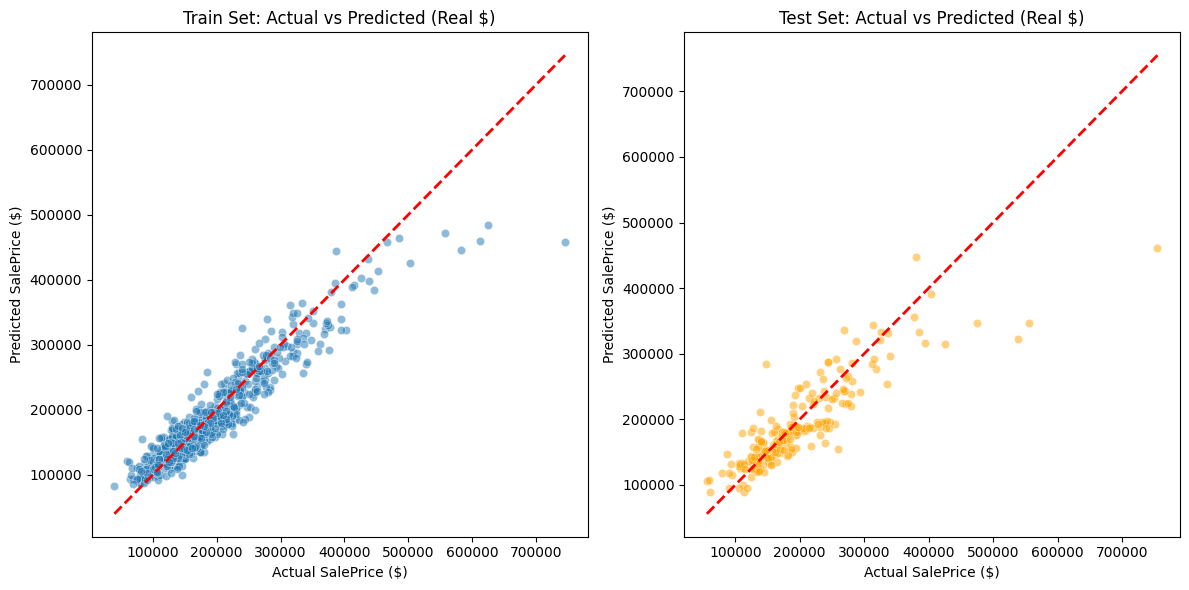

In [6]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Extract the best model found by GridSearchCV
best_model = search.best_estimator_

# 2. Make predictions (These output Logarithmic values)
y_train_pred_log = best_model.predict(X_train)
y_test_pred_log = best_model.predict(X_test)

# 3. Inverse Transform: Convert Log-Dollars back to Real Dollars
# Using expm1 to reverse the log1p transformation applied during Feature Engineering
y_train_real = np.expm1(y_train)
y_test_real = np.expm1(y_test)

y_train_pred_real = np.expm1(y_train_pred_log)
y_test_pred_real = np.expm1(y_test_pred_log)

# 4. Function to calculate and print the financial metrics in Real Dollars
def print_evaluation_metrics(y_true, y_pred, set_name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse) 
    
    print(f"--- {set_name} Set Performance (Real Dollars) ---")
    print(f"R2 Score: {r2:.3f}")
    print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
    print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}\n")

# 5. Output the performance reports
print_evaluation_metrics(y_train_real, y_train_pred_real, "Train")
print_evaluation_metrics(y_test_real, y_test_pred_real, "Test")

# 6. Generate the Actual vs Predicted visual performance charts
plt.figure(figsize=(12, 6))

# Train Set Plot
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_train_real, y=y_train_pred_real, alpha=0.5)
plt.plot([y_train_real.min(), y_train_real.max()], [y_train_real.min(), y_train_real.max()], 'r--', lw=2)
plt.title('Train Set: Actual vs Predicted (Real $)')
plt.xlabel('Actual SalePrice ($)')
plt.ylabel('Predicted SalePrice ($)')

# Test Set Plot
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test_real, y=y_test_pred_real, alpha=0.5, color='orange')
plt.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--', lw=2)
plt.title('Test Set: Actual vs Predicted (Real $)')
plt.xlabel('Actual SalePrice ($)')
plt.ylabel('Predicted SalePrice ($)')

plt.tight_layout()
plt.show()

## 6. Model Comparison

After evaluating our optimized Random Forest, we will now establish a baseline using a simpler model to verify if the added complexity provides a significant performance gain.



### 6.1 Baseline Model: Linear Regression

Linear Regression serves as our primary benchmark. It is a simple, fast, and interpretable model that assumes a linear relationship between the features and the target variable. We will train it and reverse the logarithmic transformation to get predictions in real dollars.

=== LINEAR REGRESSION PERFORMANCE ===
--- Train Set Performance (Real Dollars) ---
R2 Score: 0.760
Mean Absolute Error (MAE): $17,498.12
Root Mean Squared Error (RMSE): $37,871.79

--- Test Set Performance (Real Dollars) ---
R2 Score: 0.878
Mean Absolute Error (MAE): $18,394.25
Root Mean Squared Error (RMSE): $30,012.98



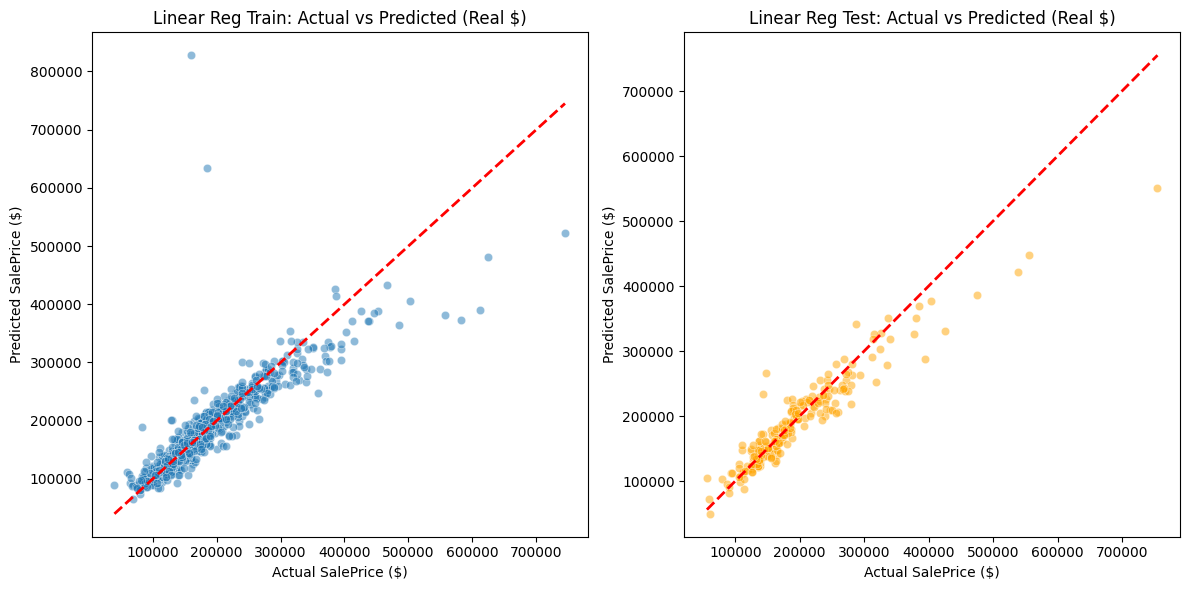

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup and train Linear Regression
lin_reg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
lin_reg_pipe.fit(X_train, y_train)

# 2. Predict and inverse transform to real dollars (Train and Test)
pred_train_lin_log = lin_reg_pipe.predict(X_train)
pred_test_lin_log = lin_reg_pipe.predict(X_test)

pred_train_lin_real = np.expm1(pred_train_lin_log)
pred_test_lin_real = np.expm1(pred_test_lin_log)

# 3. Output performance metrics (reusing function from Step 5)
print("=== LINEAR REGRESSION PERFORMANCE ===")
print_evaluation_metrics(y_train_real, pred_train_lin_real, "Train")
print_evaluation_metrics(y_test_real, pred_test_lin_real, "Test")

# 4. Generate visual performance charts
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_train_real, y=pred_train_lin_real, alpha=0.5)
plt.plot([y_train_real.min(), y_train_real.max()], [y_train_real.min(), y_train_real.max()], 'r--', lw=2)
plt.title('Linear Reg Train: Actual vs Predicted (Real $)')
plt.xlabel('Actual SalePrice ($)')
plt.ylabel('Predicted SalePrice ($)')

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test_real, y=pred_test_lin_real, alpha=0.5, color='orange')
plt.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--', lw=2)
plt.title('Linear Reg Test: Actual vs Predicted (Real $)')
plt.xlabel('Actual SalePrice ($)')
plt.ylabel('Predicted SalePrice ($)')

plt.tight_layout()
plt.show()

### 6.2 Baseline Model: Decision Tree Regressor

We also include a standard Decision Tree. Since a Random Forest is an ensemble of many trees, comparing it against a single tree helps us quantify the exact accuracy gained by using the complex ensemble approach.

=== DECISION TREE PERFORMANCE ===
--- Train Set Performance (Real Dollars) ---
R2 Score: 1.000
Mean Absolute Error (MAE): $8.48
Root Mean Squared Error (RMSE): $178.39

--- Test Set Performance (Real Dollars) ---
R2 Score: 0.742
Mean Absolute Error (MAE): $27,397.06
Root Mean Squared Error (RMSE): $43,686.09



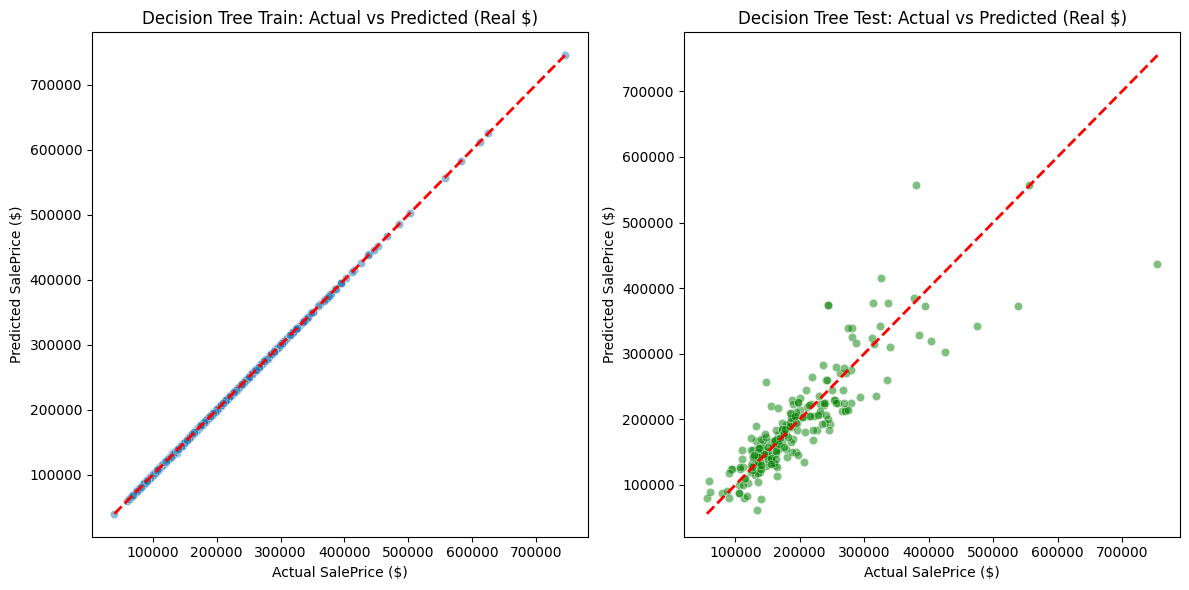

In [8]:
from sklearn.tree import DecisionTreeRegressor

# 1. Setup and train Decision Tree
tree_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', DecisionTreeRegressor(random_state=42))
])
tree_pipe.fit(X_train, y_train)

# 2. Predict and inverse transform to real dollars
pred_train_tree_log = tree_pipe.predict(X_train)
pred_test_tree_log = tree_pipe.predict(X_test)

pred_train_tree_real = np.expm1(pred_train_tree_log)
pred_test_tree_real = np.expm1(pred_test_tree_log)

# 3. Output performance metrics
print("=== DECISION TREE PERFORMANCE ===")
print_evaluation_metrics(y_train_real, pred_train_tree_real, "Train")
print_evaluation_metrics(y_test_real, pred_test_tree_real, "Test")

# 4. Generate visual performance charts
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_train_real, y=pred_train_tree_real, alpha=0.5)
plt.plot([y_train_real.min(), y_train_real.max()], [y_train_real.min(), y_train_real.max()], 'r--', lw=2)
plt.title('Decision Tree Train: Actual vs Predicted (Real $)')
plt.xlabel('Actual SalePrice ($)')
plt.ylabel('Predicted SalePrice ($)')

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test_real, y=pred_test_tree_real, alpha=0.5, color='green')
plt.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--', lw=2)
plt.title('Decision Tree Test: Actual vs Predicted (Real $)')
plt.xlabel('Actual SalePrice ($)')
plt.ylabel('Predicted SalePrice ($)')

plt.tight_layout()
plt.show()

### 6.3 Model Comparison & Selection

Now we bring all predictions together to compare their performance on the Test Set. We will evaluate the models based on the R2 Score and the Mean Absolute Error (MAE) in real dollars to select the best engine for our dashboard.

In [9]:
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error

# We reuse y_test_real and y_test_pred_real from Step 5 (Random Forest)
comparison_df = pd.DataFrame({
    "Model": ["Random Forest (Optimized)", "Linear Regression", "Decision Tree"],
    "R2 Score": [
        r2_score(y_test_real, y_test_pred_real),
        r2_score(y_test_real, pred_test_lin_real),
        r2_score(y_test_real, pred_test_tree_real)
    ],
    "MAE (Real $)": [
        mean_absolute_error(y_test_real, y_test_pred_real),
        mean_absolute_error(y_test_real, pred_test_lin_real),
        mean_absolute_error(y_test_real, pred_test_tree_real)
    ]
})

print("--- Final Model Comparison (Test Set) ---")
display(comparison_df.round(3))

--- Final Model Comparison (Test Set) ---


,Model,R2 Score,MAE (Real $)
0,Random Forest (Optimized),0.749,27014.949
1,Linear Regression,0.878,18394.255
2,Decision Tree,0.742,27397.061


## 7. Save the Trained Model

As shown in the comparison above, the **Linear Regression** model unexpectedly outperformed the complex Random Forest, providing the highest R2 Score (0.878) and the lowest error margin (MAE). 

Following the principle of simplicity and efficiency, we will select the Linear Regression as our final model. We will serialize this pipeline and the training columns order to be used in our Streamlit application.

In [10]:
import joblib
import os

version = 'v1'
file_path = f'../outputs/ml_pipeline/predict_housing/{version}'
os.makedirs(file_path, exist_ok=True)

# Save the winning Random Forest pipeline
joblib.dump(best_model, f'{file_path}/random_forest_pipeline.pkl')

# Save the training columns to ensure identical ordering in the Streamlit app
joblib.dump(X_train.columns.to_list(), f'{file_path}/train_columns.pkl')

print(f"✅ Success! Winning model and feature columns saved to: {file_path}/")

✅ Success! Winning model and feature columns saved to: ../outputs/ml_pipeline/predict_housing/v1/
